### Библиотеки

In [22]:
import sys
sys.path.append('../data')
sys.path.append('../src')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

import boto3
import io
from dotenv import dotenv_values
config = dotenv_values("../.env")

from feature_engineering import FeatureEngineering
from model import Estimator
from metric import FinEffect

from pmdarima.model_selection import train_test_split
from tqdm import tqdm

from sklearn.metrics import mean_absolute_error

### Данные

In [23]:
session = boto3.session.Session()
s3 = session.client(
    service_name='s3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id = config['AWS_ACCESS_KEY_ID'],
    aws_secret_access_key = config['AWS_SECRET_ACCESS_KEY']
)

In [24]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/work_df.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
work_df = pd.read_csv(csv_data)

work_df['Timestamp'] = pd.to_datetime(work_df['Timestamp'])
work_df = work_df.set_index('Timestamp')
work_df

,not_working_day
Timestamp,
2017-01-09,0.0
2017-01-10,0.0
2017-01-11,0.0
2017-01-12,0.0
2017-01-13,0.0
...,...
2021-03-27,1.0
2021-03-28,1.0
2021-03-29,0.0


In [25]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/rate_usa.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
rate_usa = pd.read_csv(csv_data)

rate_usa['Timestamp'] = pd.to_datetime(rate_usa['Date'])
rate_usa = rate_usa.set_index('Timestamp').drop(columns=['Date'], axis=1)
rate_usa

,rate_usa
Timestamp,
1950-01-01,1.5
1950-01-02,1.5
1950-01-03,1.5
1950-01-04,1.5
1950-01-05,1.5
...,...
2024-01-27,5.5
2024-01-28,5.5
2024-01-29,5.5


In [26]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/exchange_usd.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
exchange_usd = pd.read_csv(csv_data)

exchange_usd['Timestamp'] = pd.to_datetime(exchange_usd['Date'])
exchange_usd = exchange_usd.set_index('Timestamp').drop(columns=['Date'], axis=1)
exchange_usd

,usd
Timestamp,
2017-01-10,59.8961
2017-01-11,59.9533
2017-01-12,60.1614
2017-01-13,59.4978
2017-01-14,59.3700
...,...
2021-03-27,75.7576
2021-03-28,75.8287
2021-03-29,75.8287


In [27]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/exchange_eur.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
exchange_eur = pd.read_csv(csv_data)

exchange_eur['Timestamp'] = pd.to_datetime(exchange_eur['Date'])
exchange_eur = exchange_eur.set_index('Timestamp').drop(columns=['Date'], axis=1)
exchange_eur

,eur
Timestamp,
2017-01-10,63.1125
2017-01-11,63.5445
2017-01-12,63.5184
2017-01-13,63.2759
2017-01-14,63.1222
...,...
2021-03-27,89.2576
2021-03-28,89.3490
2021-03-29,89.3490


In [28]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/rate_russ.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
rate_russ = pd.read_csv(csv_data)

rate_russ['Timestamp'] = pd.to_datetime(rate_russ['Date'])
rate_russ = rate_russ.set_index('Timestamp').drop(columns=['Date'], axis=1)
rate_russ

,rate_russ,real_inflation,target_inflation
Timestamp,,,
2017-01-01,10.0,5.00,4.0
2017-01-02,10.0,4.60,4.0
2017-01-03,10.0,4.60,4.0
2017-01-04,10.0,4.60,4.0
2017-01-05,10.0,4.60,4.0
...,...,...,...
2021-11-27,8.5,8.39,4.0
2021-11-28,8.5,8.39,4.0
2021-11-29,8.5,8.39,4.0


In [29]:
raw_data = pd.read_excel('../data/Project 2_2023.xlsx', sheet_name='Data')
raw_data = raw_data.rename(columns={'Date':'Timestamp'})
raw_data['Timestamp'] = pd.to_datetime(raw_data['Timestamp'])
raw_data = raw_data.set_index('Timestamp')
raw_data = raw_data.asfreq('D')
raw_data = raw_data.fillna(0)
raw_data

,Income,Outcome,Balance
Timestamp,,,
2017-01-09,1.343028,1.487865,-0.144836
2017-01-10,1.068610,1.194182,-0.125572
2017-01-11,0.944429,0.936663,0.007767
2017-01-12,1.672202,0.875379,0.796823
2017-01-13,0.955924,0.975645,-0.019721
...,...,...,...
2021-03-27,0.000000,0.000000,0.000000
2021-03-28,0.000000,0.000000,0.000000
2021-03-29,2.356883,3.370738,-1.013855


In [30]:
target = raw_data['Balance'][1:]
lag = raw_data.drop(columns=['Balance'], axis=1).shift(1)[1:]

### Генерация признаков

In [31]:
fe = FeatureEngineering(lag, work_df, n_lags=10, attrs=['Income', 'Outcome'], tax_days=[15, 25], alphas=[0.2, 0.7])
featured_df = fe.generate_features()

In [32]:
featured_df = pd.merge(featured_df, rate_usa, right_index=True, left_index=True, how='left')
featured_df = pd.merge(featured_df, rate_russ, right_index=True, left_index=True, how='left')
featured_df = pd.merge(featured_df, exchange_eur, right_index=True, left_index=True, how='left')
featured_df = pd.merge(featured_df, exchange_usd, right_index=True, left_index=True, how='left')

In [33]:
featured_df

,is_holiday,is_not_working_day,is_year_2017,is_year_2018,is_year_2019,is_year_2020,is_year_2021,is_month_1,is_month_2,is_month_3,...,Outcome_ewma_0.2_mean,Outcome_ewma_0.2_std,Outcome_ewma_0.7_mean,Outcome_ewma_0.7_std,rate_usa,rate_russ,real_inflation,target_inflation,eur,usd
Timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-10,0,0.0,1,0,0,0,0,1,0,0,...,1.487865,0.000000,1.487865,0.000000,1.25,10.0,4.6,4.0,63.1125,59.8961
2017-01-11,0,0.0,1,0,0,0,0,1,0,0,...,1.324708,0.207665,1.261955,0.207665,1.25,10.0,4.6,4.0,63.5445,59.9533
2017-01-12,0,0.0,1,0,0,0,0,1,0,0,...,1.165673,0.273328,1.027932,0.243791,1.25,10.0,4.6,4.0,63.5184,60.1614
2017-01-13,0,0.0,1,0,0,0,0,1,0,0,...,1.067335,0.264163,0.920273,0.165382,1.25,10.0,4.6,4.0,63.2759,59.4978
2017-01-14,0,1.0,1,0,0,0,0,1,0,0,...,1.040059,0.219987,0.959128,0.097198,1.25,10.0,4.6,4.0,63.1222,59.3700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-27,0,1.0,0,0,0,0,1,0,0,1,...,2.681280,1.491957,4.168465,1.209635,0.25,5.0,5.5,4.0,89.2576,75.7576
2021-03-28,0,1.0,0,0,0,0,1,0,0,1,...,2.145024,1.753515,1.250540,2.888787,0.25,5.0,5.5,4.0,89.3490,75.8287
2021-03-29,0,0.0,0,0,0,0,1,0,0,1,...,1.716019,1.813300,0.375162,1.793064,0.25,5.0,5.5,4.0,89.3490,75.8287


In [34]:
featured_df.describe()

,is_holiday,is_not_working_day,is_year_2017,is_year_2018,is_year_2019,is_year_2020,is_year_2021,is_month_1,is_month_2,is_month_3,...,Outcome_ewma_0.2_mean,Outcome_ewma_0.2_std,Outcome_ewma_0.7_mean,Outcome_ewma_0.7_std,rate_usa,rate_russ,real_inflation,target_inflation,eur,usd
count,1542.000000,1542.000000,1542.000000,1542.000000,1542.000000,1542.000000,1542.000000,1542.000000,1542.000000,1542.000000,...,1542.000000,1542.000000,1542.000000,1542.000000,1542.000000,1542.000000,1542.000000,1542.0,1542.000000,1542.000000
mean,0.049287,0.325551,0.230869,0.236706,0.236706,0.237354,0.058366,0.094682,0.091440,0.100519,...,1.130106,0.842717,1.132515,0.692084,1.744812,6.880350,3.723022,4.0,74.680984,65.090815
std,0.216536,0.468732,0.421525,0.425198,0.425198,0.425599,0.234510,0.292871,0.288327,0.300788,...,0.345687,0.245402,0.705255,0.449825,1.019547,1.629978,1.046323,0.0,8.146407,6.318731
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.232198,0.000000,0.000922,0.000000,0.250000,4.250000,2.200000,4.0,59.612400,55.671700
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.893731,0.669898,0.461953,0.332881,0.250000,5.500000,2.700000,4.0,69.519375,59.354375
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.095610,0.804680,1.247640,0.617736,2.000000,7.250000,3.700000,4.0,73.070800,64.246900
75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.311836,0.965590,1.587858,0.959774,2.500000,7.750000,4.400000,4.0,78.502650,69.025225
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.079474,2.086493,4.255411,3.261008,3.000000,10.000000,5.800000,4.0,93.757000,80.881500


In [35]:
for i in featured_df.columns:
    print(i)

is_holiday
is_not_working_day
is_year_2017
is_year_2018
is_year_2019
is_year_2020
is_year_2021
is_month_1
is_month_2
is_month_3
is_month_4
is_month_5
is_month_6
is_month_7
is_month_8
is_month_9
is_month_10
is_month_11
is_month_12
is_day_1
is_day_2
is_day_3
is_day_4
is_day_5
is_day_6
is_day_7
is_day_8
is_day_9
is_day_10
is_day_11
is_day_12
is_day_13
is_day_14
is_day_15
is_day_16
is_day_17
is_day_18
is_day_19
is_day_20
is_day_21
is_day_22
is_day_23
is_day_24
is_day_25
is_day_26
is_day_27
is_day_28
is_day_29
is_day_30
is_day_31
is_weekday_0
is_weekday_1
is_weekday_2
is_weekday_3
is_weekday_4
is_weekday_5
is_weekday_6
is_tax_15
is_tax_25
Income_lag_1
Income_lag_2
Income_lag_3
Income_lag_4
Income_lag_5
Income_lag_6
Income_lag_7
Income_lag_8
Income_lag_9
Income_window_2D_mean
Income_window_2D_median
Income_window_2D_min
Income_window_2D_max
Income_window_2D_std
Income_window_2D_skew
Income_window_2D_kurt
Income_window_5D_mean
Income_window_5D_median
Income_window_5D_min
Income_window_5D_max


### Отбор признаков

In [36]:
metric = FinEffect()

#### Фильтрационные методы

##### mutual_info

In [37]:
from sklearn.feature_selection import mutual_info_regression

In [38]:
disc_features = [1 if x[:3] == 'is_' else 0 for x in list(featured_df.columns)]


res = mutual_info_regression(
    featured_df,
    target.astype(float),
    discrete_features=disc_features
)

sorted_res = sorted(zip(featured_df.columns, res), key=lambda x: x[1], reverse=True)

Text(0.5, 1.0, 'Mutual info features distribution')

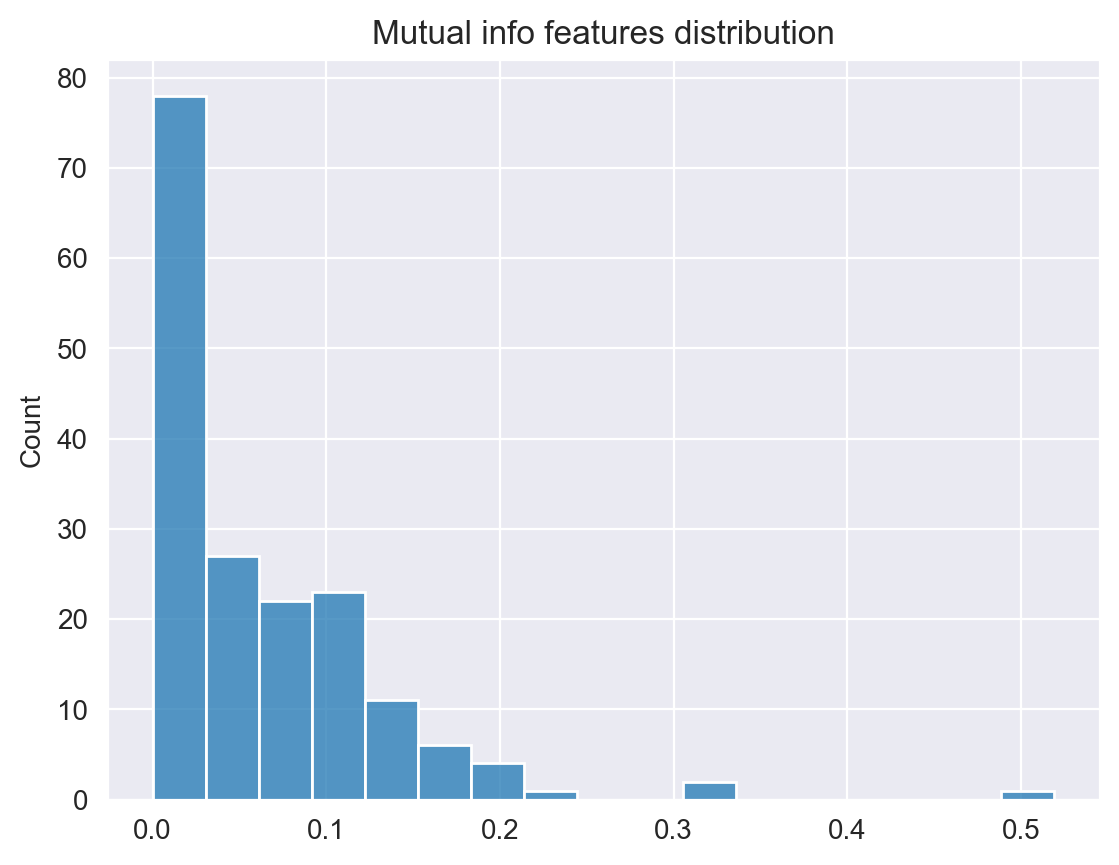

In [39]:
sns.histplot([x[1] for x in sorted_res])
plt.title("Mutual info features distribution")

In [40]:
# накладываем минимальное ограничение на показатель 0.01
sorted_res = [x for x in sorted_res if x[1]>=0.01][:50]
top_features = [x[0] for x in sorted_res]

for f, s in sorted_res:
    print(f"{f}: {round(s, 2)}")

is_not_working_day: 0.52
Income_lag_6: 0.34
Outcome_lag_6: 0.33
Outcome_ewma_0.7_mean: 0.23
Outcome_window_5D_kurt: 0.2
Income_ewma_0.7_mean: 0.2
Outcome_window_5D_skew: 0.19
Income_window_5D_kurt: 0.18
Outcome_window_5D_mean: 0.17
is_weekday_6: 0.17
Outcome_window_5D_min: 0.17
Outcome_window_5D_std: 0.16
Income_window_5D_min: 0.16
Income_window_5D_std: 0.16
Income_window_5D_skew: 0.15
Income_window_5D_mean: 0.15
Outcome_window_10D_kurt: 0.15
Income_window_2D_min: 0.15
Income_window_10D_kurt: 0.15
is_weekday_5: 0.13
Income_lag_8: 0.13
Outcome_window_2D_min: 0.13
Income_window_60D_mean: 0.13
Outcome_window_60D_std: 0.12
Income_expanding_max: 0.12
Income_window_60D_skew: 0.12
Income_lag_2: 0.12
Income_window_2D_std: 0.12
Outcome_window_60D_median: 0.12
Outcome_expanding_std: 0.11
Income_lag_3: 0.11
Income_window_2D_median: 0.11
rate_usa: 0.11
Income_ewma_0.7_std: 0.11
Outcome_window_10D_skew: 0.11
Income_window_2D_mean: 0.11
Income_window_10D_skew: 0.1
Income_lag_4: 0.1
Income_window_60D

In [41]:
y_train, y_test = train_test_split(target, train_size=0.9)
X_train, X_test = featured_df.loc[y_train.index, top_features], featured_df.loc[y_test.index, top_features]

In [42]:
model = Estimator(5, 1, 5, 1, 5)
model.fit(X_train, y_train)

In [43]:
preds = []
for new_value, idx in tqdm(zip(y_test, y_test.index), total=len(y_test)):
    forecast = model.predict(X_test.loc[[idx]])
    preds.append(forecast)
    model.update(X_test.loc[[idx]], np.array([new_value]))
preds = np.array(preds).reshape(-1, )

100%|██████████| 155/155 [01:29<00:00,  1.73it/s]


Text(0.5, 0.98, 'Mae: 0.2238')

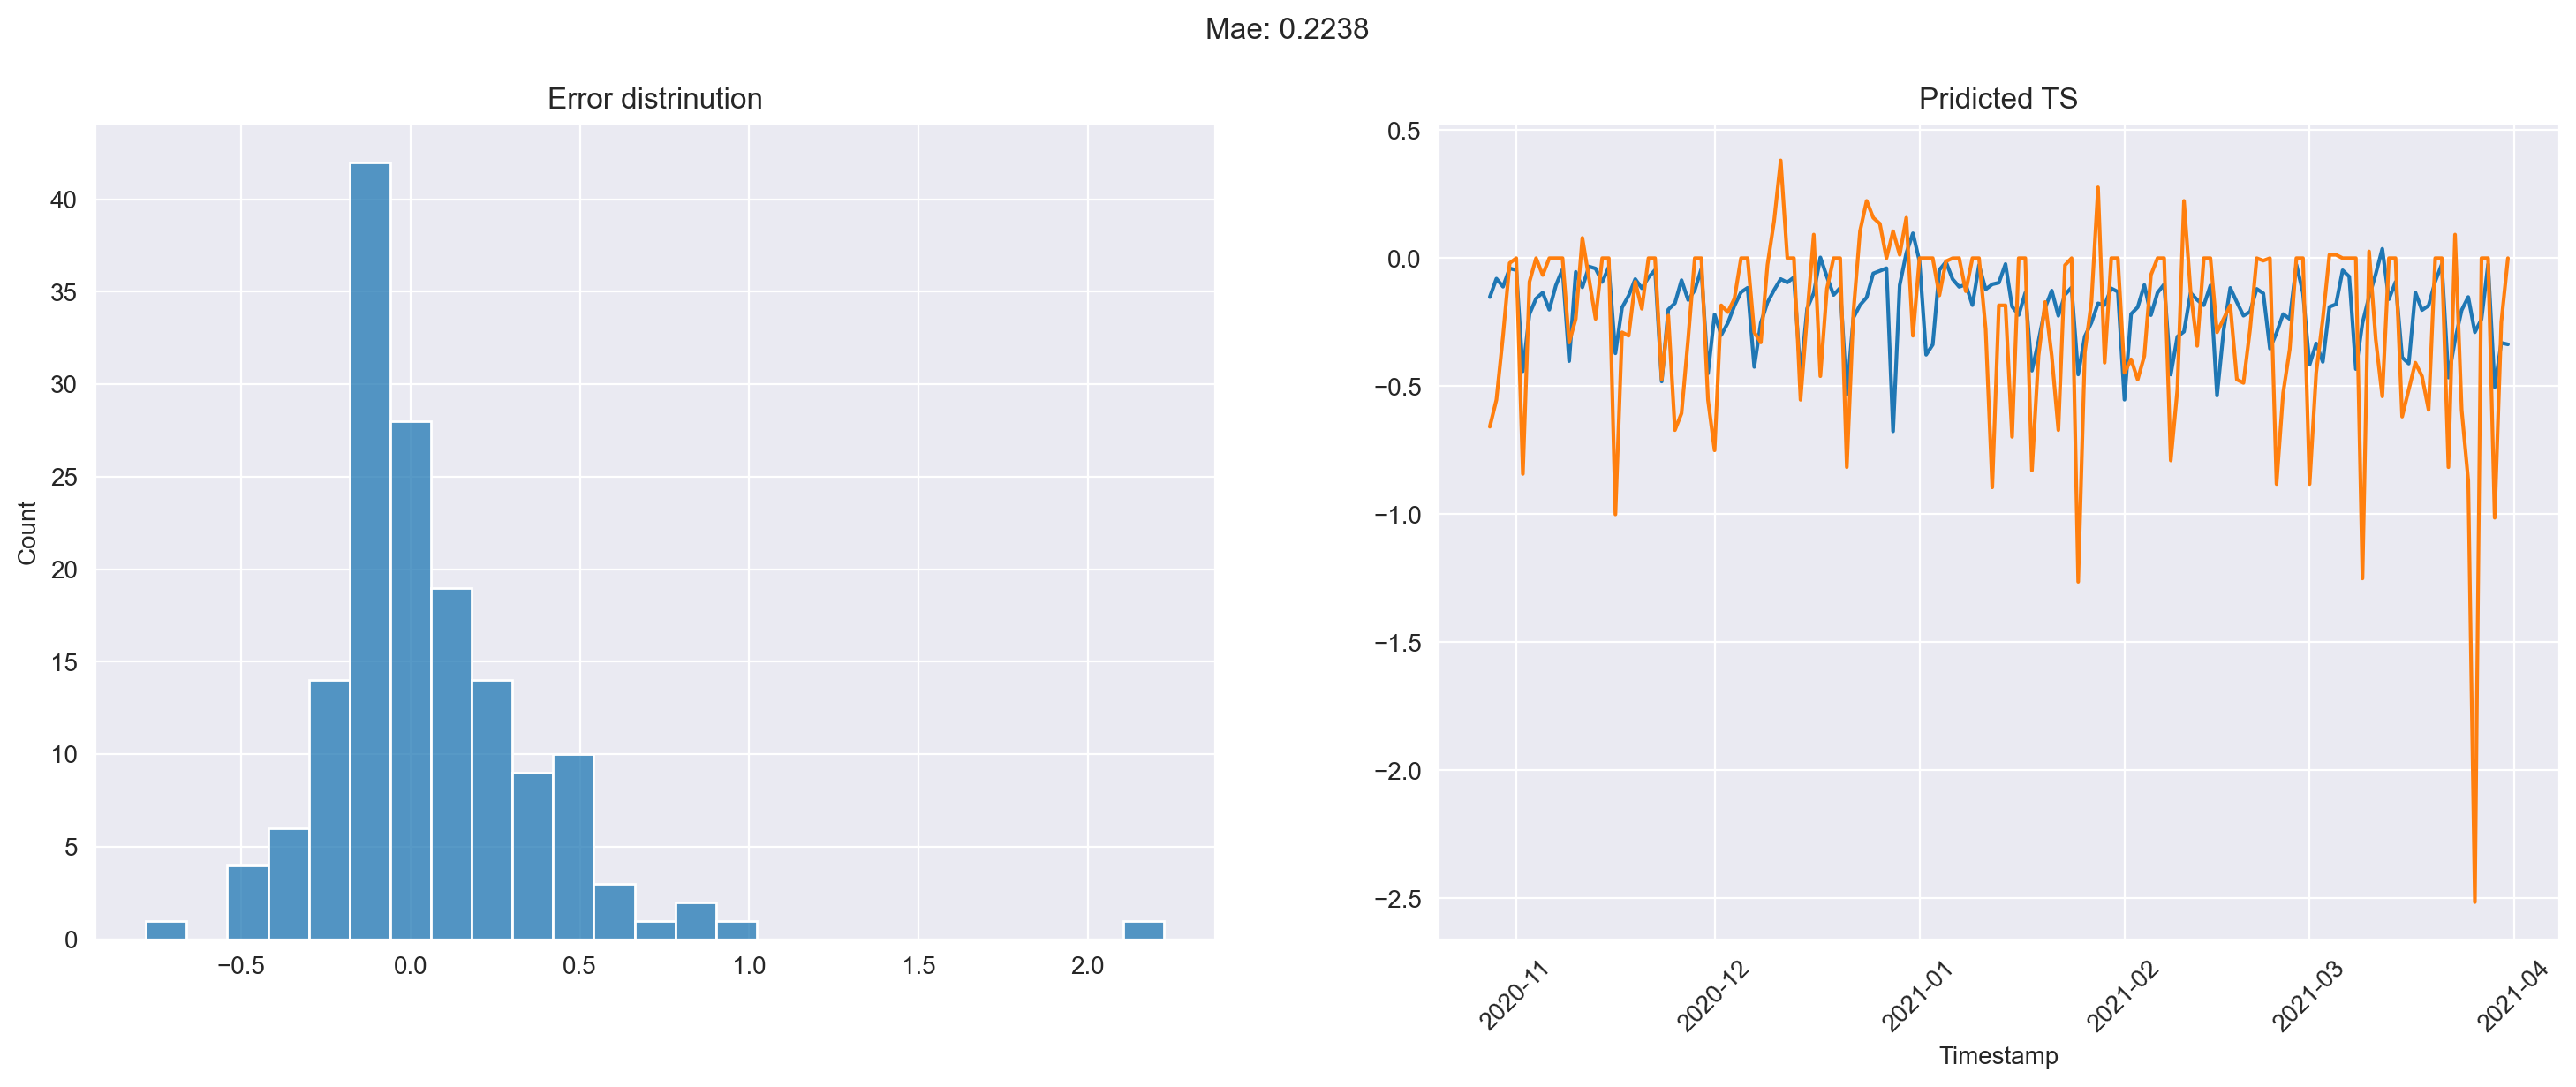

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

errors = preds - y_test.to_numpy()
sns.histplot(errors, ax=ax[0])
ax[0].set_title('Error distrinution')

sns.lineplot(x=y_test.index, y=preds, ax=ax[1])
sns.lineplot(x=y_test.index, y=y_test.to_numpy(), ax=ax[1])
ax[1].set_title('Pridicted TS')
ax[1].tick_params(axis='x', rotation=45)

plt.suptitle(f"Mae: {round(mean_absolute_error(y_test.to_numpy(), preds), 4)}")

#### phik

In [73]:
import phik

In [74]:
y_train, y_test = train_test_split(target, train_size=0.9)
X_train, X_test = featured_df.loc[y_train.index], featured_df.loc[y_test.index]

In [76]:
df = pd.concat([y_train, X_train], axis=1).phik_matrix()
features = df['Balance'].sort_values(ascending=False)
top_features = features[:11].index[1:].copy()

for f, s in zip(features.index, features):
    print(f"{f}: {round(s, 2)}")

interval columns not set, guessing: ['Balance', 'is_holiday', 'is_not_working_day', 'is_year_2017', 'is_year_2018', 'is_year_2019', 'is_year_2020', 'is_year_2021', 'is_month_1', 'is_month_2', 'is_month_3', 'is_month_4', 'is_month_5', 'is_month_6', 'is_month_7', 'is_month_8', 'is_month_9', 'is_month_10', 'is_month_11', 'is_month_12', 'is_day_1', 'is_day_2', 'is_day_3', 'is_day_4', 'is_day_5', 'is_day_6', 'is_day_7', 'is_day_8', 'is_day_9', 'is_day_10', 'is_day_11', 'is_day_12', 'is_day_13', 'is_day_14', 'is_day_15', 'is_day_16', 'is_day_17', 'is_day_18', 'is_day_19', 'is_day_20', 'is_day_21', 'is_day_22', 'is_day_23', 'is_day_24', 'is_day_25', 'is_day_26', 'is_day_27', 'is_day_28', 'is_day_29', 'is_day_30', 'is_day_31', 'is_weekday_0', 'is_weekday_1', 'is_weekday_2', 'is_weekday_3', 'is_weekday_4', 'is_weekday_5', 'is_weekday_6', 'is_tax_15', 'is_tax_25', 'Income_lag_1', 'Income_lag_2', 'Income_lag_3', 'Income_lag_4', 'Income_lag_5', 'Income_lag_6', 'Income_lag_7', 'Income_lag_8', 'Inco

Text(0.5, 1.0, 'Phik features distribution')

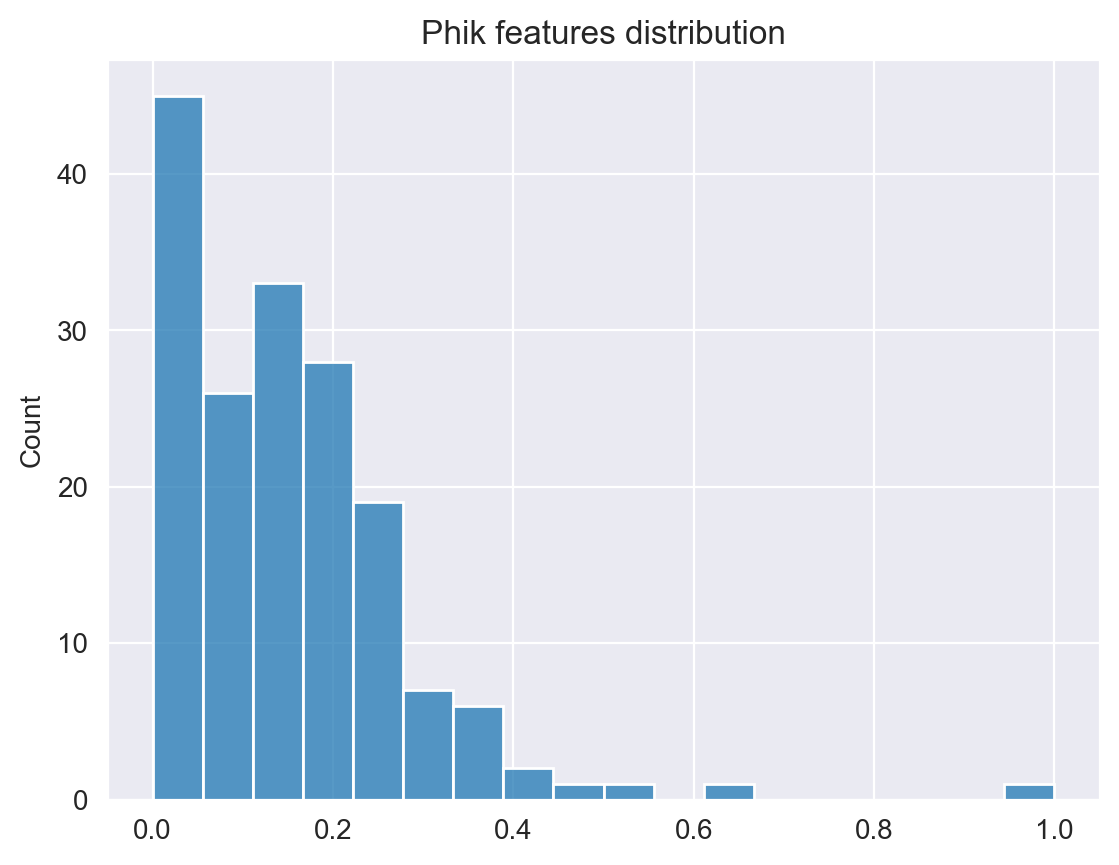

In [48]:
sns.histplot(features.values)
plt.title("Phik features distribution")

In [49]:
y_train, y_test = train_test_split(target, train_size=0.9)
X_train, X_test = featured_df.loc[y_train.index, top_features], featured_df.loc[y_test.index, top_features]

In [50]:
model = Estimator(5, 1, 5, 1, 5)
model.fit(X_train, y_train)

In [51]:
preds = []
for new_value, idx in tqdm(zip(y_test, y_test.index), total=len(y_test)):
    forecast = model.predict(X_test.loc[[idx]])
    preds.append(forecast)
    model.update(X_test.loc[[idx]], np.array([new_value]))
preds = np.array(preds).reshape(-1, )

100%|██████████| 155/155 [01:45<00:00,  1.47it/s]


Text(0.5, 0.98, 'Mae: 0.2232')

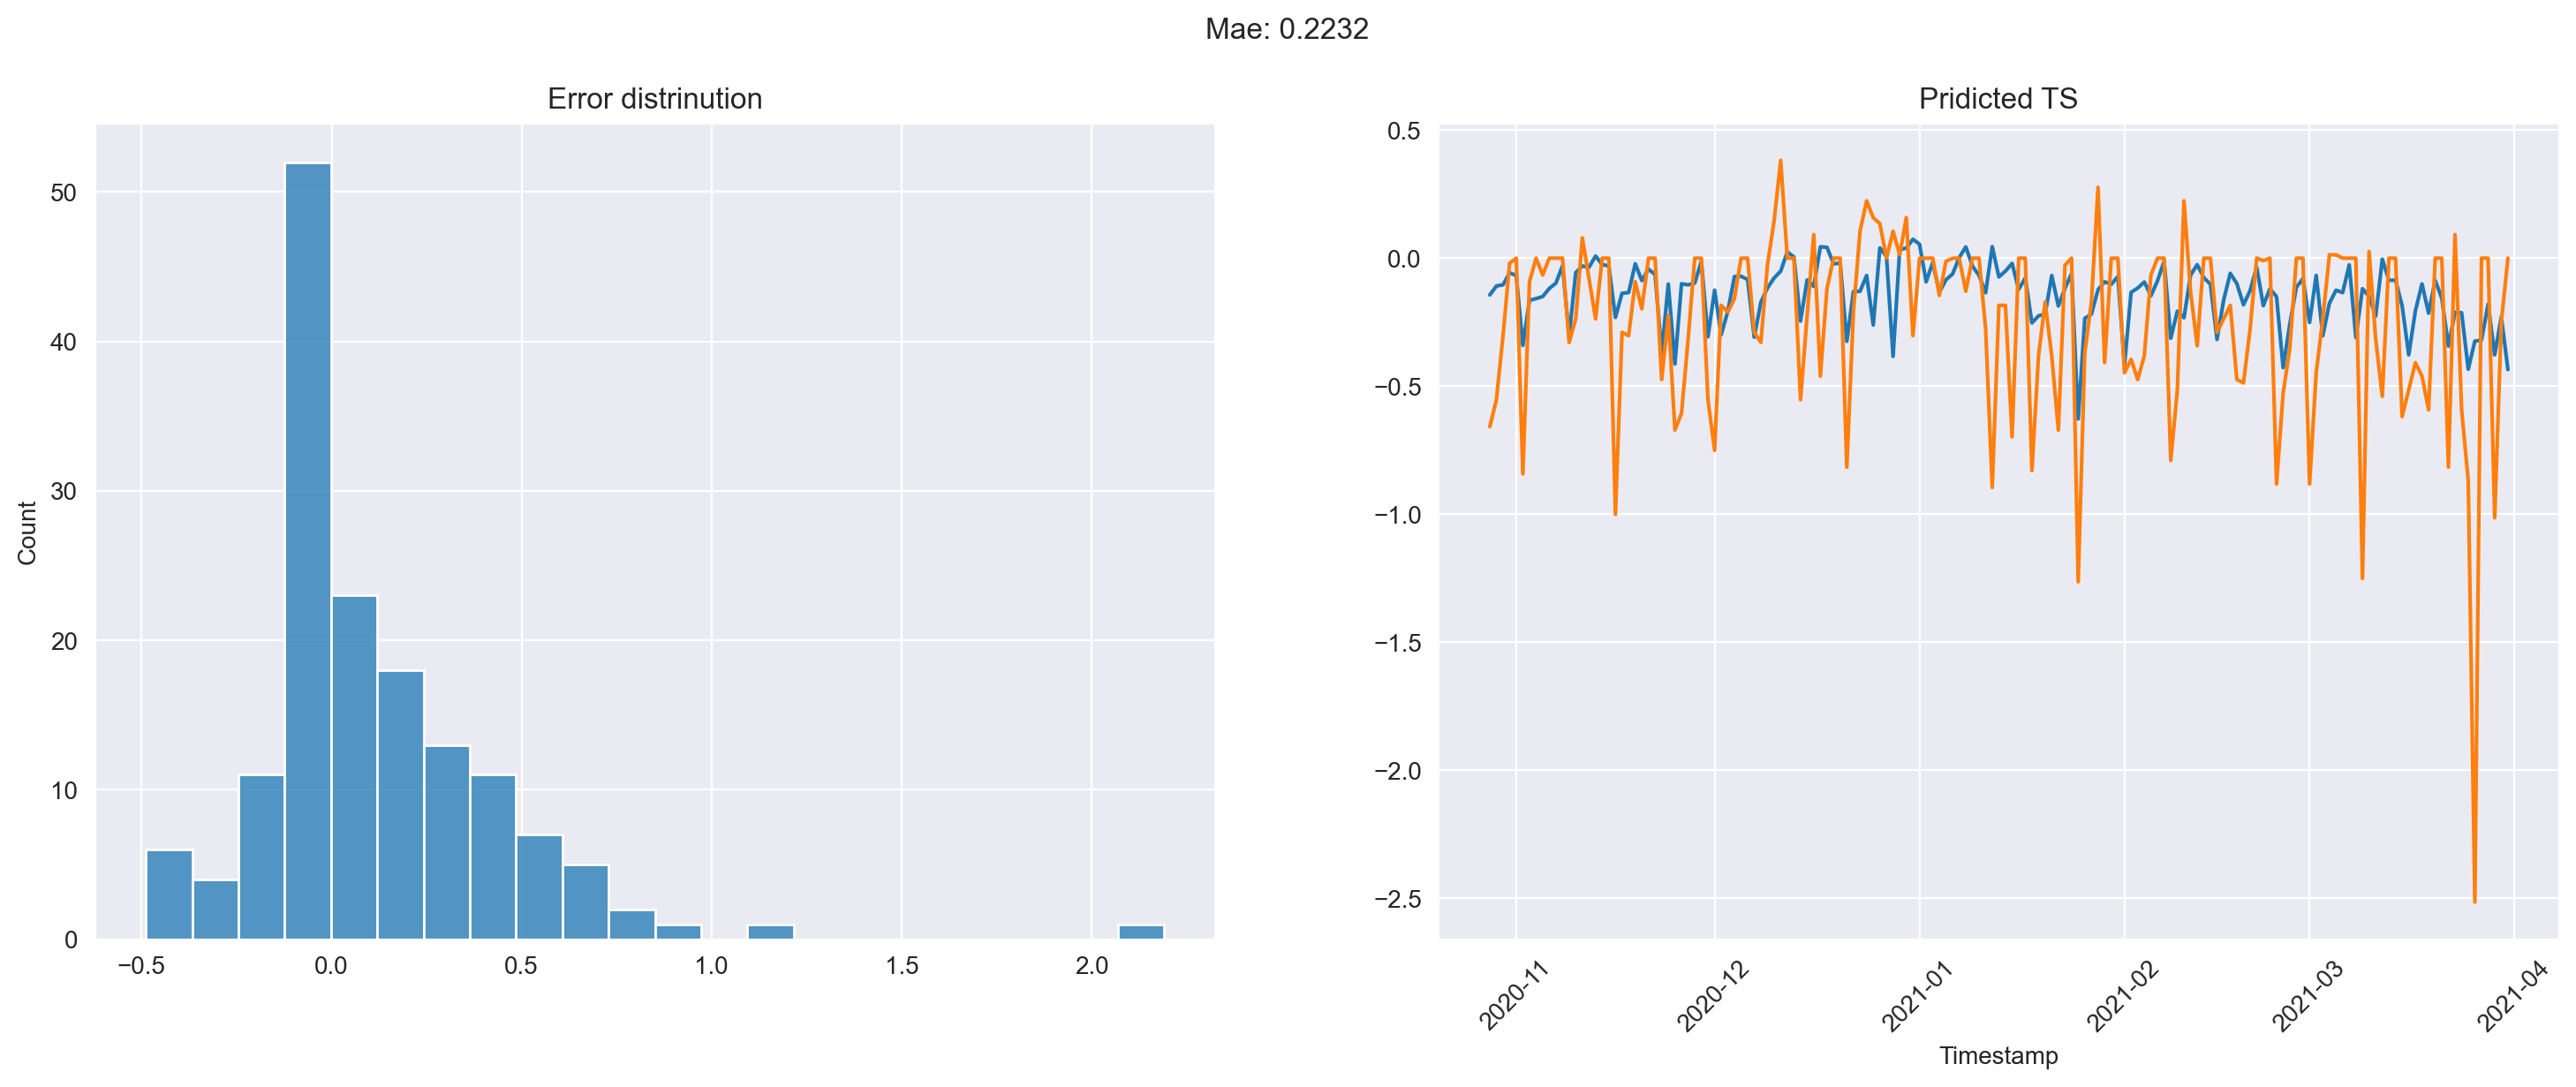

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

errors = preds - y_test.to_numpy()
sns.histplot(errors, ax=ax[0])
ax[0].set_title('Error distrinution')

sns.lineplot(x=y_test.index, y=preds, ax=ax[1])
sns.lineplot(x=y_test.index, y=y_test.to_numpy(), ax=ax[1])
ax[1].set_title('Pridicted TS')
ax[1].tick_params(axis='x', rotation=45)

plt.suptitle(f"Mae: {round(mean_absolute_error(y_test.to_numpy(), preds), 4)}")

#### Conditional mutual info

In [53]:
#!git clone https://github.com/gregversteeg/NPEET.git

In [79]:
from npeet import entropy_estimators as ee

In [80]:
y_train, y_test = train_test_split(target, train_size=0.9)
X_train, X_test = featured_df.loc[y_train.index], featured_df.loc[y_test.index]

In [81]:
res = []
for col in X_train.columns:
    score = ee.cmi(y_train, X_train[col], y_train.shift(1).fillna(0))
    res.append((col, score))
sorted_res = sorted(res, key=lambda x: x[1], reverse=True)
cols = [x[0] for x in sorted_res[:10]]

for f, s in sorted_res:
    print(f"{f}: {round(s, 2)}")

is_not_working_day: 0.77
Income_lag_6: 0.47
Outcome_lag_6: 0.45
is_weekday_5: 0.35
is_weekday_6: 0.32
Outcome_window_2D_min: 0.3
Income_window_2D_min: 0.29
Income_lag_1: 0.29
Outcome_ewma_0.7_mean: 0.28
Outcome_window_5D_min: 0.28
Outcome_window_5D_skew: 0.28
Income_window_5D_min: 0.27
Income_window_5D_skew: 0.26
Income_window_10D_kurt: 0.26
Income_ewma_0.7_mean: 0.26
Outcome_lag_1: 0.26
Outcome_lag_8: 0.24
Outcome_window_10D_kurt: 0.24
Income_window_5D_std: 0.24
Outcome_ewma_0.7_std: 0.23
Outcome_window_2D_std: 0.23
Income_window_2D_median: 0.23
Outcome_lag_5: 0.23
Income_window_2D_mean: 0.22
Outcome_window_5D_mean: 0.22
Income_window_2D_std: 0.22
Income_lag_8: 0.22
Outcome_window_5D_std: 0.22
Outcome_window_5D_kurt: 0.22
is_weekday_0: 0.21
Outcome_window_10D_skew: 0.21
Income_ewma_0.7_std: 0.21
Income_window_5D_mean: 0.21
Income_window_10D_skew: 0.2
Income_lag_5: 0.19
Outcome_window_2D_median: 0.19
Outcome_lag_3: 0.19
Outcome_window_2D_mean: 0.19
Income_window_5D_kurt: 0.19
Income_la

Text(0.5, 1.0, 'CMI features distribution')

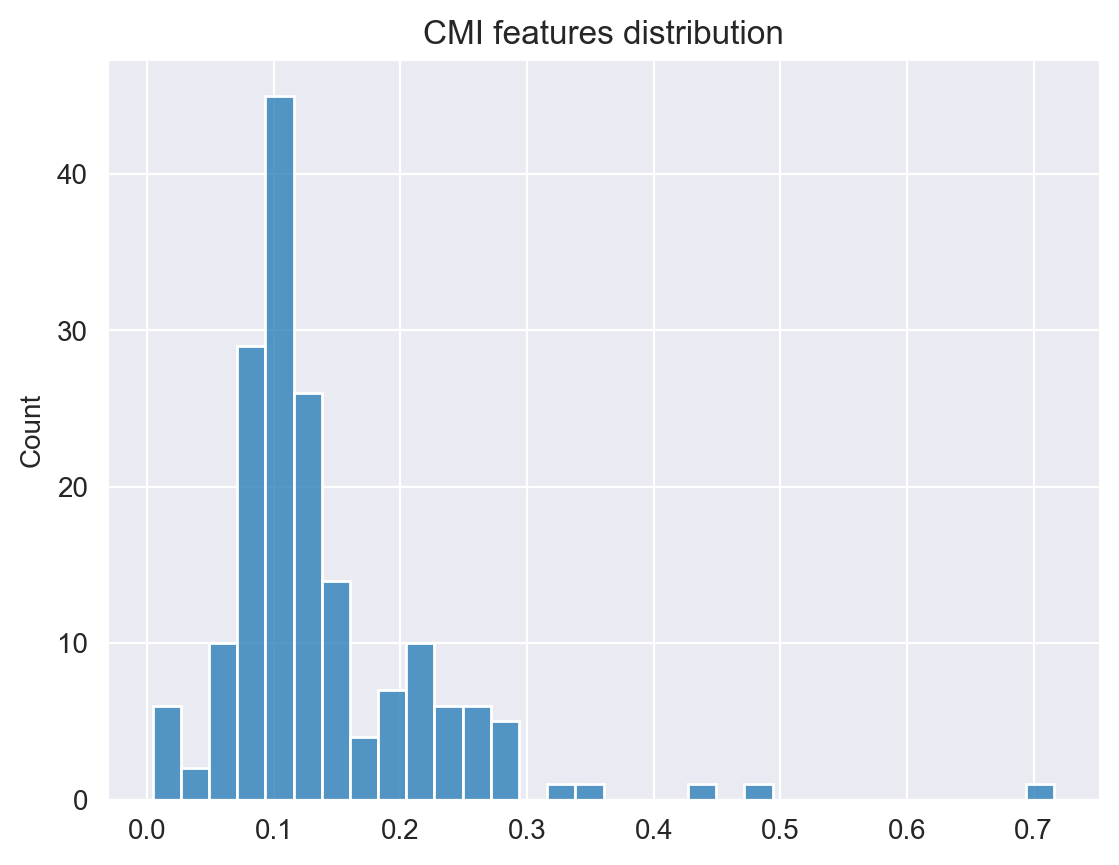

In [57]:
sns.histplot([x[1] for x in sorted_res])
plt.title("CMI features distribution")

In [58]:
y_train, y_test = train_test_split(target, train_size=0.9)
X_train, X_test = featured_df.loc[y_train.index, cols], featured_df.loc[y_test.index, cols]

In [59]:
model = Estimator(5, 1, 5, 1, 5)
model.fit(X_train, y_train)

In [60]:
preds = []
for new_value, idx in tqdm(zip(y_test, y_test.index), total=len(y_test)):
    forecast = model.predict(X_test.loc[[idx]])
    preds.append(forecast)
    model.update(X_test.loc[[idx]], np.array([new_value]))
preds = np.array(preds).reshape(-1, )

100%|██████████| 155/155 [01:02<00:00,  2.49it/s]


Text(0.5, 0.98, 'Mae: 0.2223')

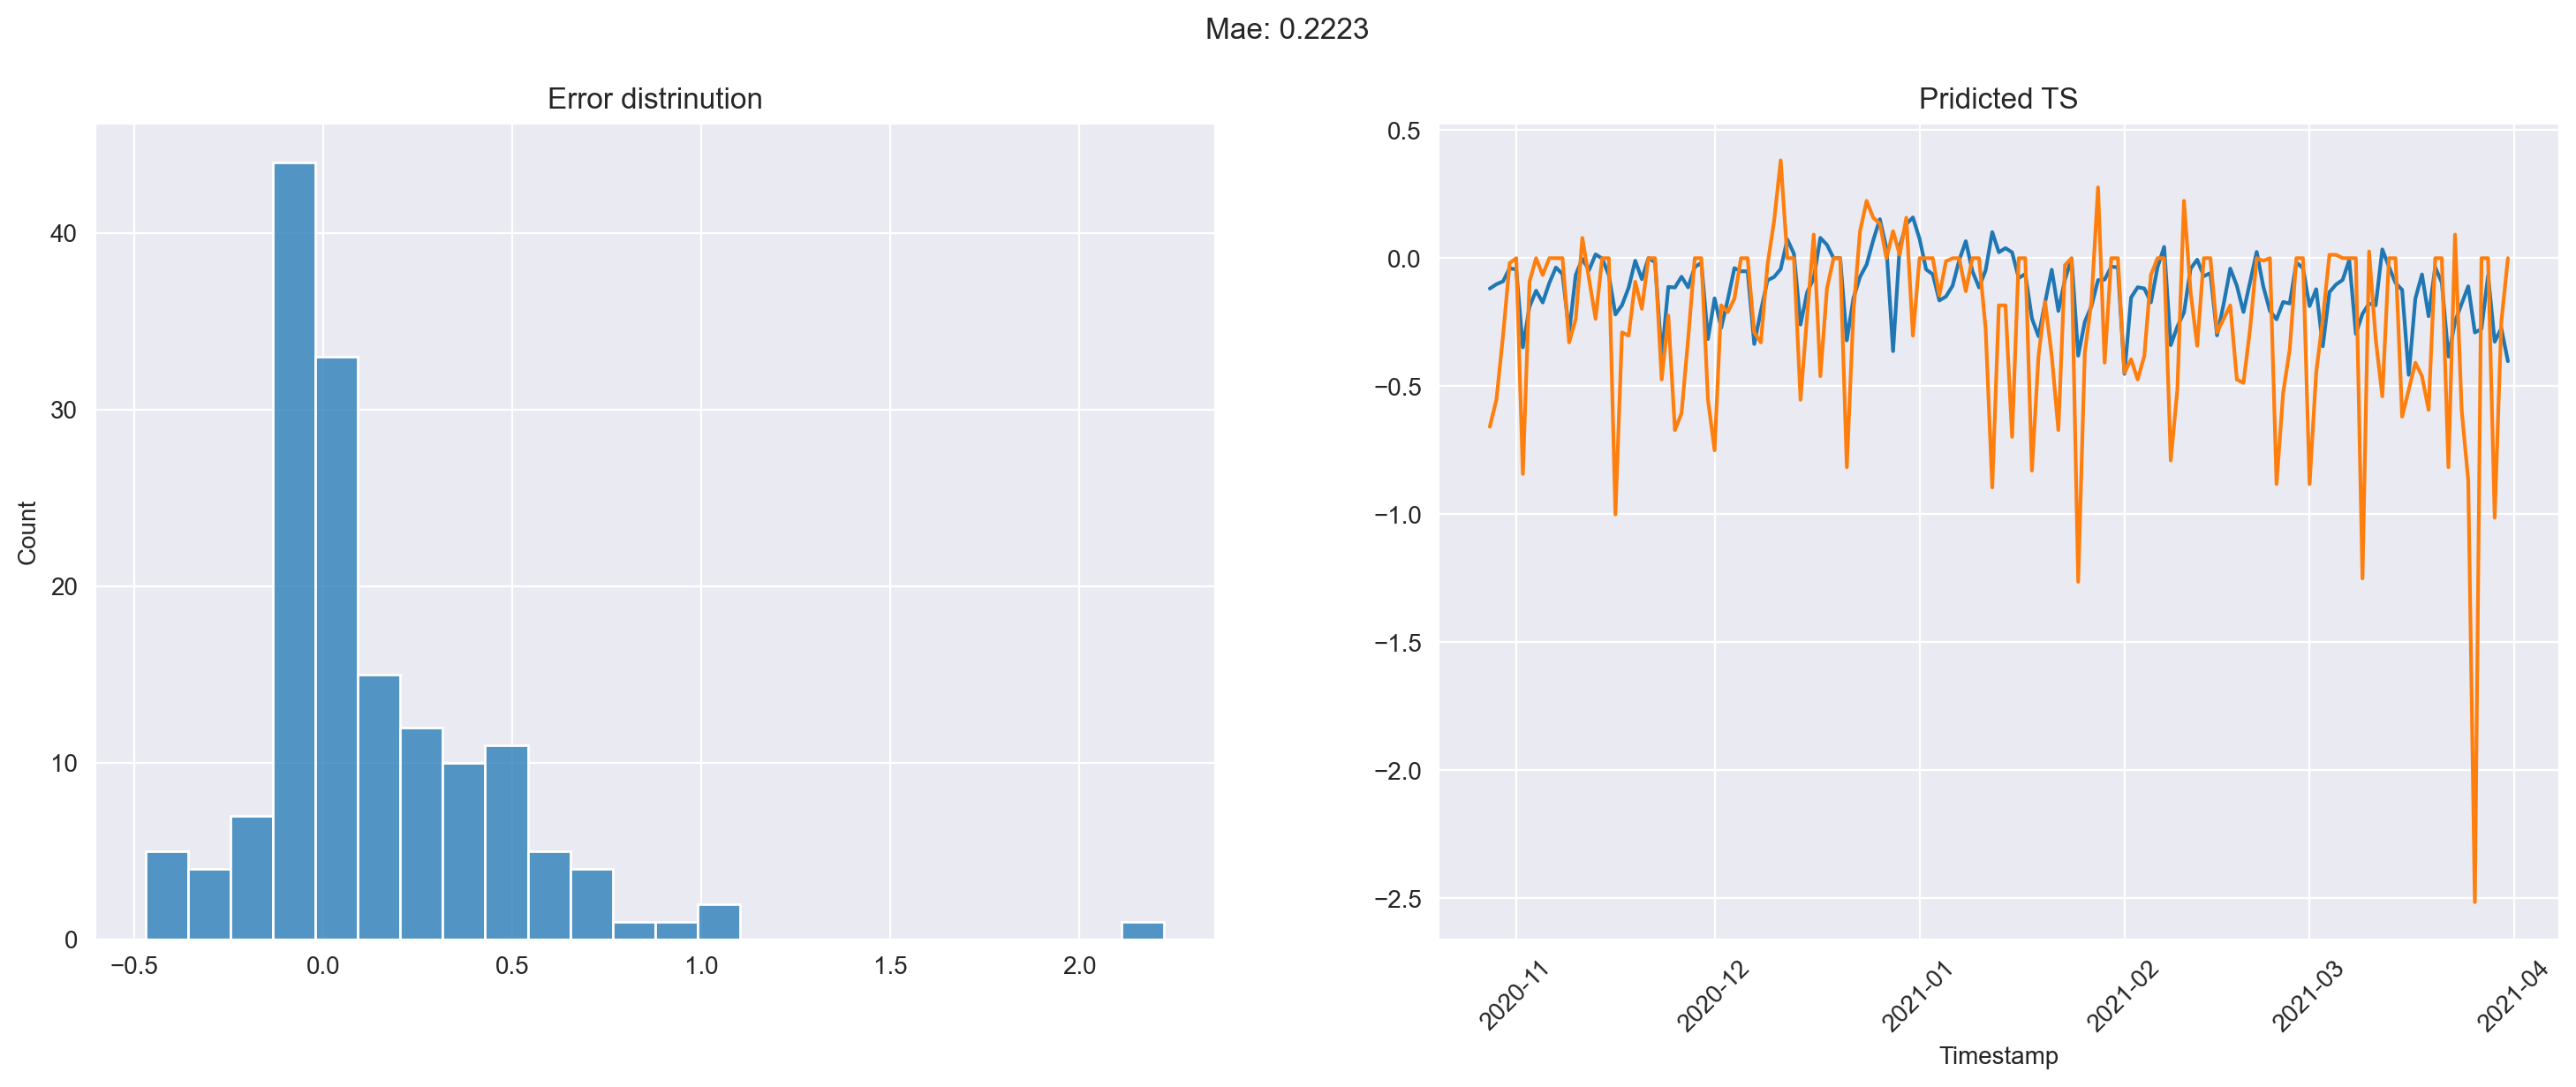

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

errors = preds - y_test.to_numpy()
sns.histplot(errors, ax=ax[0])
ax[0].set_title('Error distrinution')

sns.lineplot(x=y_test.index, y=preds, ax=ax[1])
sns.lineplot(x=y_test.index, y=y_test.to_numpy(), ax=ax[1])
ax[1].set_title('Pridicted TS')
ax[1].tick_params(axis='x', rotation=45)

plt.suptitle(f"Mae: {round(mean_absolute_error(y_test.to_numpy(), preds), 4)}")

#### Встроенные методы

In [82]:
from sklearn import linear_model

In [83]:
y_train, y_test = train_test_split(target, train_size=0.9)
X_train, X_test = featured_df.loc[y_train.index], featured_df.loc[y_test.index]

In [84]:
clf = linear_model.Lasso(alpha=0.01)
clf.fit(X_train, y_train)
idx = np.where(clf.coef_ != 0)
cols = X_train.columns[idx][:10]
cols

Index(['Income_lag_1', 'Income_lag_7', 'Income_window_2D_min',
       'Income_window_2D_std', 'Income_window_5D_kurt', 'Outcome_lag_3',
       'Outcome_lag_6', 'Outcome_window_5D_skew', 'Outcome_window_5D_kurt',
       'rate_russ'],
      dtype='object')

In [85]:
clf = linear_model.Lasso(alpha=0.05)
clf.fit(X_train, y_train)
idx = np.where(clf.coef_ != 0)
X_train.columns[idx][:10]

Index(['Income_window_5D_kurt', 'Outcome_window_5D_kurt', 'eur', 'usd'], dtype='object')

In [86]:
clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_train, y_train)
idx = np.where(clf.coef_ != 0)
X_train.columns[idx][:10]

Index(['Outcome_window_5D_kurt', 'eur'], dtype='object')

In [87]:
y_train, y_test = train_test_split(target, train_size=0.9)
X_train, X_test = featured_df.loc[y_train.index, cols], featured_df.loc[y_test.index, cols]

In [68]:
model = Estimator(5, 1, 5, 1, 5)
model.fit(X_train, y_train)

In [69]:
preds = []
for new_value, idx in tqdm(zip(y_test, y_test.index), total=len(y_test)):
    forecast = model.predict(X_test.loc[[idx]])
    preds.append(forecast)
    model.update(X_test.loc[[idx]], np.array([new_value]))
preds = np.array(preds).reshape(-1, )

100%|██████████| 155/155 [00:25<00:00,  6.08it/s]


Text(0.5, 0.98, 'Mae: 0.2247')

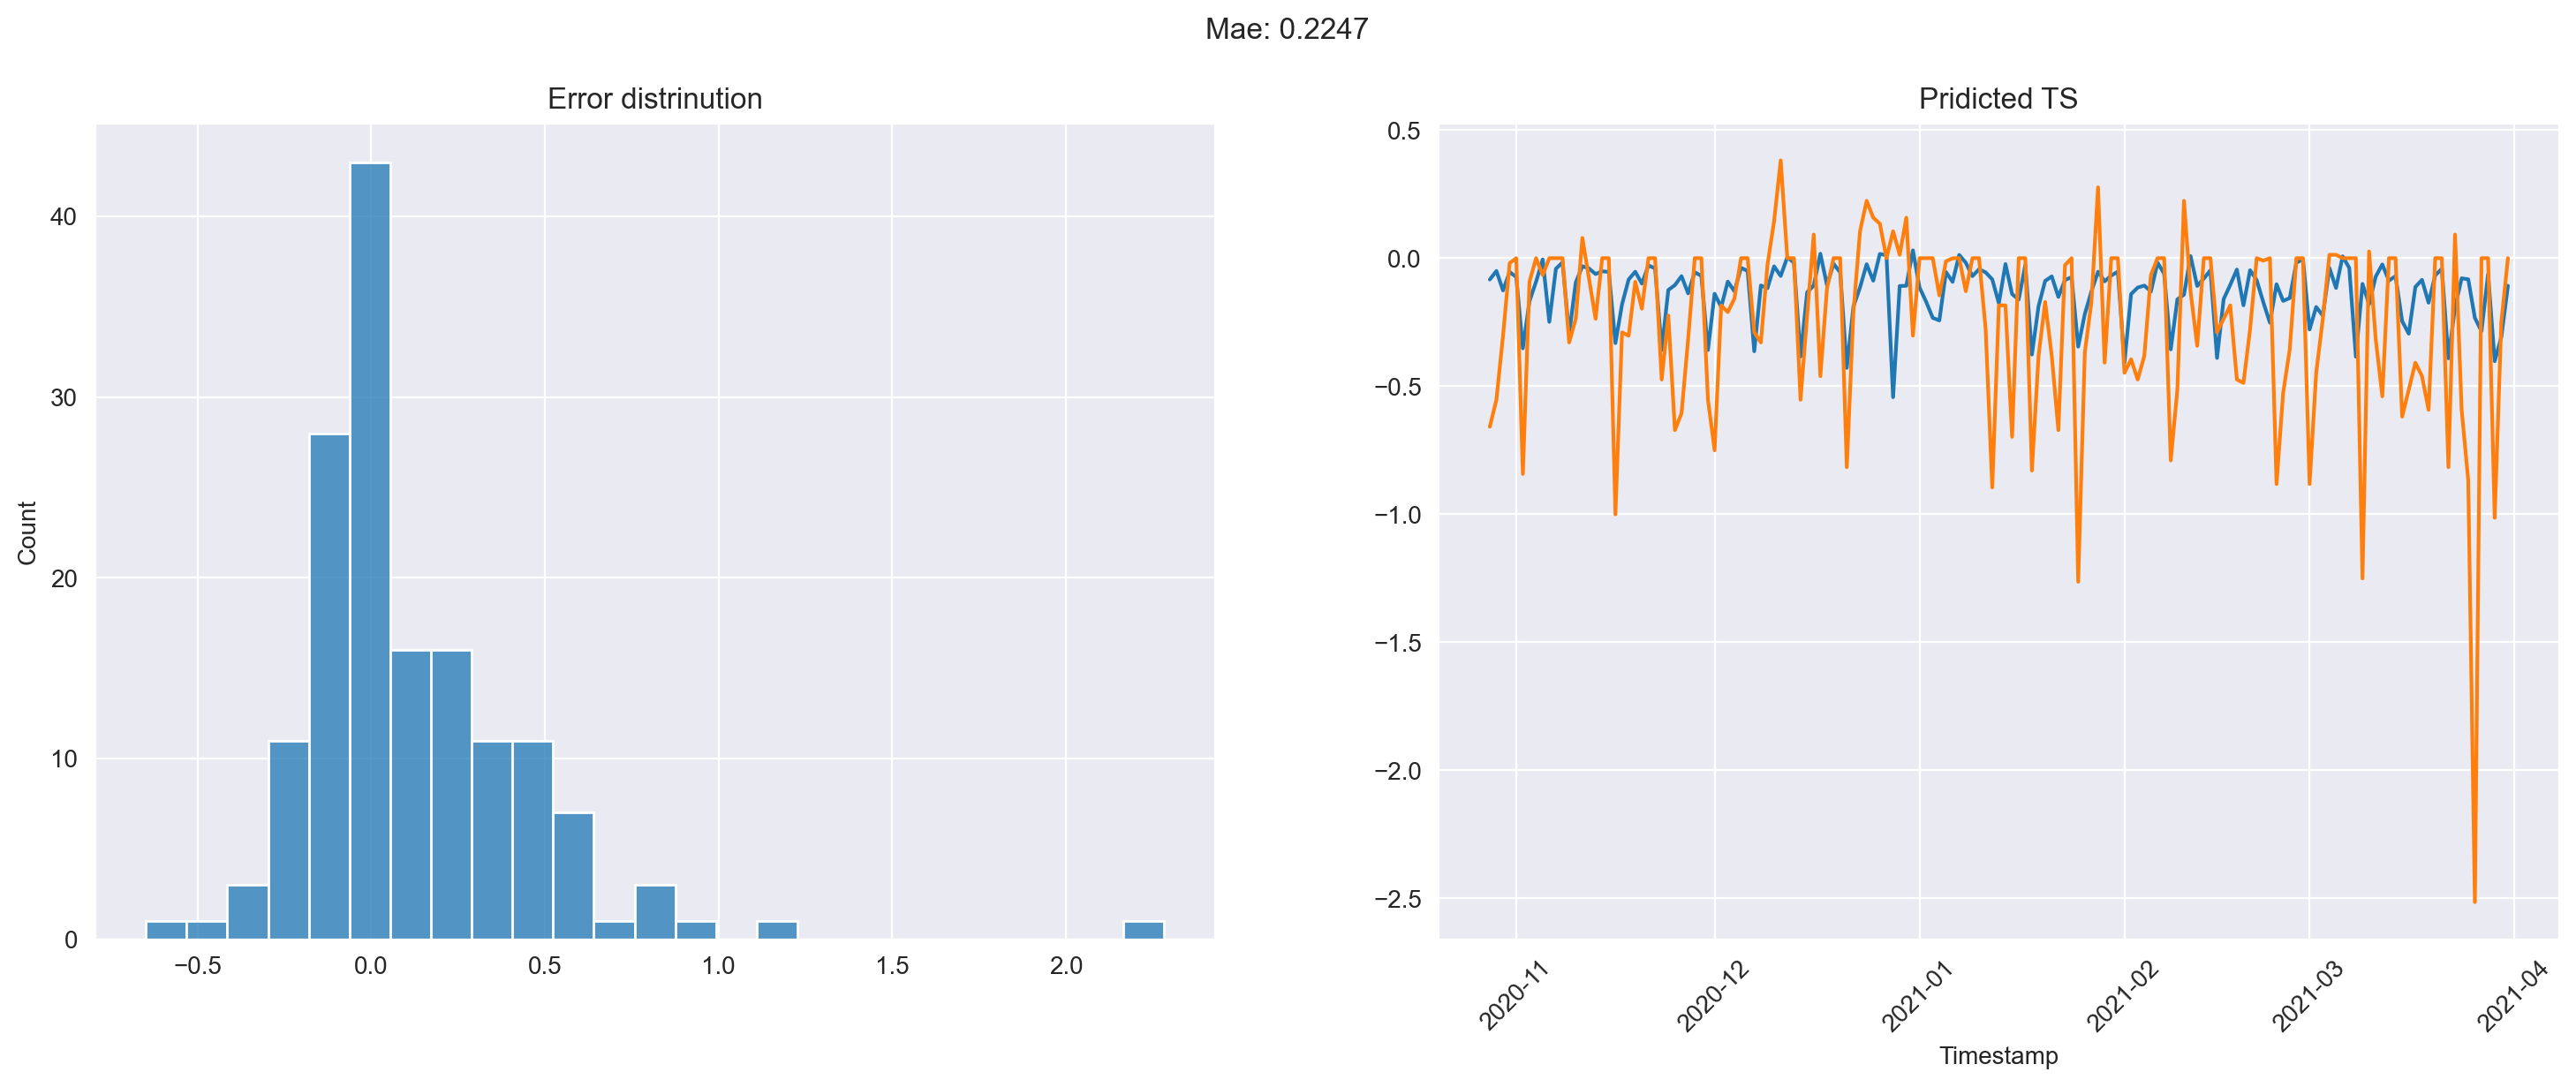

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

errors = preds - y_test.to_numpy()
sns.histplot(errors, ax=ax[0])
ax[0].set_title('Error distrinution')

sns.lineplot(x=y_test.index, y=preds, ax=ax[1])
sns.lineplot(x=y_test.index, y=y_test.to_numpy(), ax=ax[1])
ax[1].set_title('Pridicted TS')
ax[1].tick_params(axis='x', rotation=45)

plt.suptitle(f"Mae: {round(mean_absolute_error(y_test.to_numpy(), preds), 4)}")

#### Оберточные методы

In [88]:
y_train, y_test = train_test_split(target, train_size=0.9)
X_train, X_test = featured_df.loc[y_train.index], featured_df.loc[y_test.index]

In [93]:
import numpy as np
import pandas as pd
import random
from typing import Callable
from tqdm import tqdm

def random_feature_addition(
                            X_train: pd.DataFrame, 
                            y_train: pd.Series,
                            X_test: pd.DataFrame, 
                            y_test: pd.Series,
                            metric: Callable[[np.ndarray, np.ndarray], float],
                            max_features: int = 10,
                            n_iter: int = 5,
                            random_state: int = 42):
    
    random.seed(random_state)
    np.random.seed(random_state)

    all_features = list(X_train.columns)
    best_score = np.inf
    best_features = []

    for _ in range(n_iter):
        print(f'Iter: {_ + 1}')
        remaining_features = all_features.copy()
        current_features = []

        while len(current_features) < max_features and remaining_features:
            add_feature = random.choice(remaining_features)
            current_features.append(add_feature)
            remaining_features.remove(add_feature)

            # Обучаем и тестируем модель
            model = Estimator(5, 1, 5, 1, 5)
            model.fit(X_train[current_features], y_train)

            preds = []
            for new_value, idx in tqdm(zip(y_test, y_test.index), total=len(X_test), leave=False):
                forecast = model.predict(X_test.loc[[idx], current_features])
                preds.append(forecast)
                model.update(X_test.loc[[idx], current_features], np.array([new_value]))

            score = metric(y_test, preds)

            # Обновляем лучший результат
            if score < best_score:
                best_score = score
                best_features = current_features.copy()
            print(f'top_features : {best_features}, top_score : {best_score}, current_features : {best_features}, current_score : {best_score}')

    return best_features, best_score

In [94]:
random_feature_addition(X_train, y_train, X_test, y_test, mean_absolute_error)

Iter: 1


top_features : ['Outcome_expanding_skew'], top_score : 0.25771793366583473, current_features : ['Outcome_expanding_skew'], current_score : 0.25771793366583473


top_features : ['Outcome_expanding_skew', 'is_day_10'], top_score : 0.25426359162121115, current_features : ['Outcome_expanding_skew', 'is_day_10'], current_score : 0.25426359162121115


top_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021'], top_score : 0.25223507975184406, current_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021'], current_score : 0.25223507975184406


top_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std'], top_score : 0.24684906580150934, current_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std'], current_score : 0.24684906580150934


...

top_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std', 'Income_lag_6', 'Income_lag_1', 'is_day_19', 'is_day_9', 'Outcome_window_20D_min', 'is_day_5'], top_score : 0.22676047781478412, current_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std', 'Income_lag_6', 'Income_lag_1', 'is_day_19', 'is_day_9', 'Outcome_window_20D_min', 'is_day_5'], current_score : 0.22676047781478412


top_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std', 'Income_lag_6', 'Income_lag_1', 'is_day_19', 'is_day_9', 'Outcome_window_20D_min', 'is_day_5'], top_score : 0.22676047781478412, current_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std', 'Income_lag_6', 'Income_lag_1', 'is_day_19', 'is_day_9', 'Outcome_window_20D_min', 'is_day_5'], current_score : 0.22676047781478412


top_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std', 'Income_lag_6', 'Income_lag_1', 'is_day_19', 'is_day_9', 'Outcome_window_20D_min', 'is_day_5'], top_score : 0.22676047781478412, current_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std', 'Income_lag_6', 'Income_lag_1', 'is_day_19', 'is_day_9', 'Outcome_window_20D_min', 'is_day_5'], current_score : 0.22676047781478412


top_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std', 'Income_lag_6', 'Income_lag_1', 'is_day_19', 'is_day_9', 'Outcome_window_20D_min', 'is_day_5'], top_score : 0.22676047781478412, current_features : ['Outcome_expanding_skew', 'is_day_10', 'is_year_2021', 'Income_window_2D_std', 'Income_lag_6', 'Income_lag_1', 'is_day_19', 'is_day_9', 'Outcome_window_20D_min', 'is_day_5'], current_score : 0.22676047781478412


(['Outcome_expanding_skew',
  'is_day_10',
  'is_year_2021',
  'Income_window_2D_std',
  'Income_lag_6',
  'Income_lag_1',
  'is_day_19',
  'is_day_9',
  'Outcome_window_20D_min',
  'is_day_5'],
 0.22676047781478412)

__Выводы:__

* Лучше всего себя показли фильтрационные методы (победитель phik)
* Встроенне (L1) сильно зануляет большинство показателей, требуется хороший анализ относительно параметра регуляризации
* Оберточные работают на нашей модели очент долго (порядки дня), даже RFA